In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [32]:
df_index = pd.read_csv("economic_index.csv")
df_index.head()

,year,month,interest_rate,unemployment_rate,index_price
0,2017,12,2.75,5.3,1464
1,2017,11,2.50,5.3,1394
2,2017,10,2.50,5.3,1357
3,2017,9,2.50,5.3,1293
4,2017,8,2.50,5.4,1256


In [33]:
#drop unnecessary columns

df_index.drop(columns=['year', 'month'], inplace=True)
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [34]:
# check for null values
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

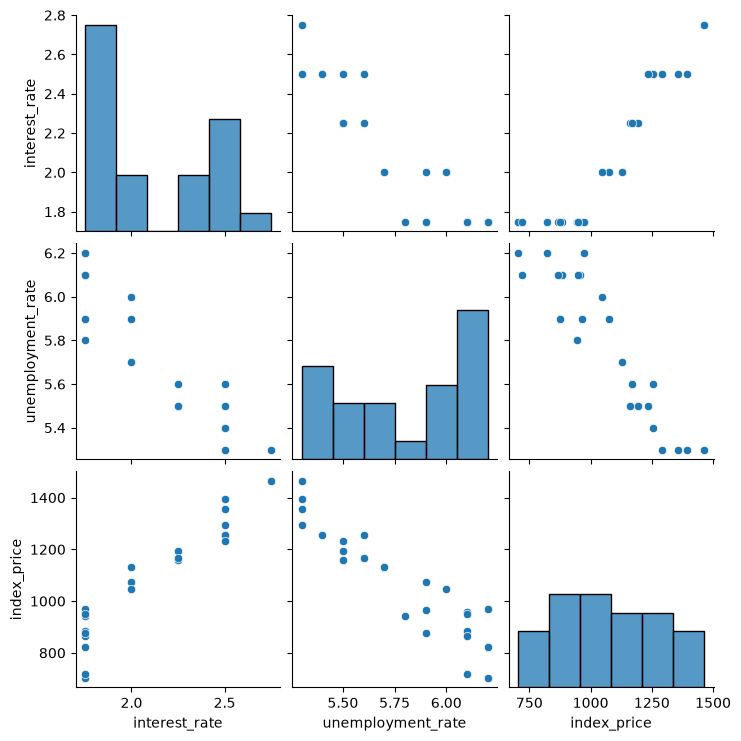

In [35]:
# visualize the data
import seaborn as sns
sns.pairplot(df_index)


In [ ]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'Unemployment Rate')

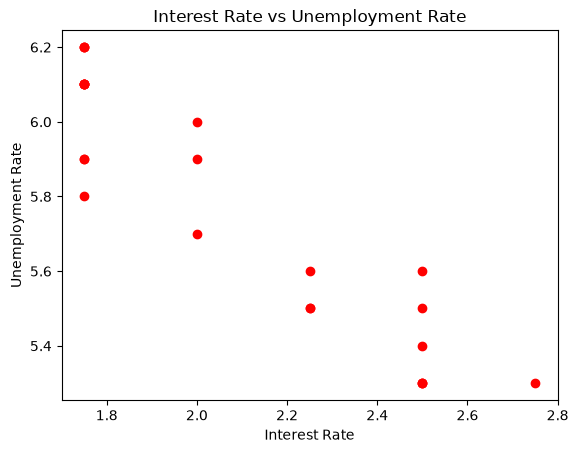

In [41]:
#visualizing data more closely

plt.scatter(df_index['interest_rate'], df_index['unemployment_rate'], color='red')
plt.title('Interest Rate vs Unemployment Rate')
plt.xlabel('Interest Rate')
plt.ylabel('Unemployment Rate')

In [43]:
#independent and dependent variables
X = df_index[['interest_rate', 'unemployment_rate']]
y = df_index['index_price']

In [45]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [46]:
y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

In [47]:
#train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#regression plot seaborn (not happening)

sns.regplot(df_index['interest_rate'], df_index['index_price'])

TypeError: regplot() takes from 0 to 1 positional arguments but 2 were given

In [54]:
#strandardize the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [55]:
# applying linear regression model
from sklearn.linear_model import LinearRegression
regression = LinearRegression()
regression.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 86.63,-114.05]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1059
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](2,)","[6.04,1.25]"


In [56]:
print(regression.coef_)
print(regression.intercept_)

[  86.63351334 -114.04857249]
1059.421052631579


In [59]:
# cross validation
from sklearn.model_selection import cross_val_score
validation_score = cross_val_score(regression, X_train, y_train, scoring='neg_mean_squared_error', cv=3)
print(validation_score)
print(np.mean(validation_score))

[-4304.75412833 -7608.56499271 -5108.77588052]
-5674.031667186762


In [60]:
#prediction
y_pred = regression.predict(X_test)
y_pred

array([1192.92068422,  846.6908733 , 1374.53556008,  879.61386031,
       1003.34428525])

In [62]:
#performance metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
adjusted_r2 = 1 - (1-r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print("Mean Squared Error:", mse, "\nMean Absolute Error:", mae, "\nRoot Mean Squared Error:", rmse, "\nR-squared:", r2, "\nAdjusted R-squared:", adjusted_r2)

Mean Squared Error: 5952.207497480538 
Mean Absolute Error: 64.74722105636567 
Root Mean Squared Error: 77.15055085662408 
R-squared: 0.8507000324705941 
Adjusted R-squared: 0.7014000649411882


8     -33.920684
16    124.309127
0      89.464440
18      4.386140
11     71.655715
Name: index_price, dtype: float64


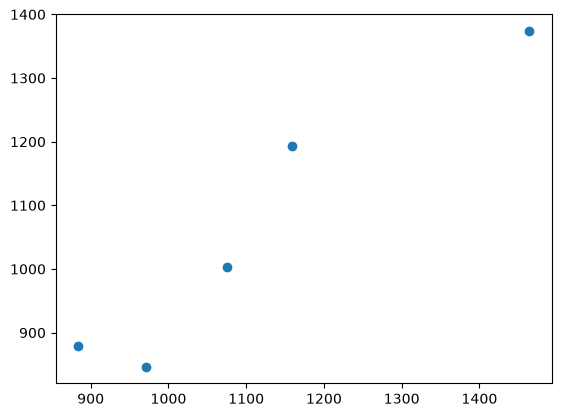

In [63]:
#assumptions of linear regression
plt.scatter(y_test, y_pred)
residuals = y_test - y_pred
print(residuals)

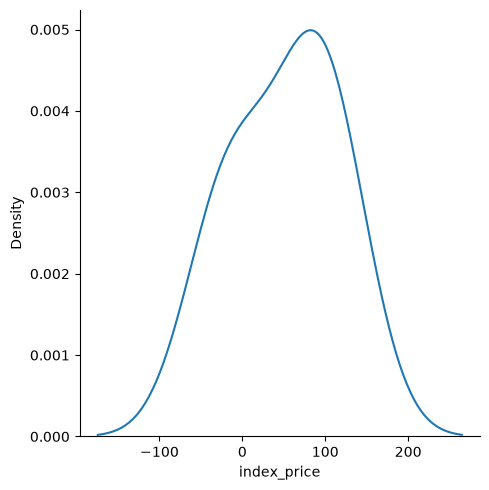

In [70]:
#plot residuals
sns.displot(residuals, kind ='kde')

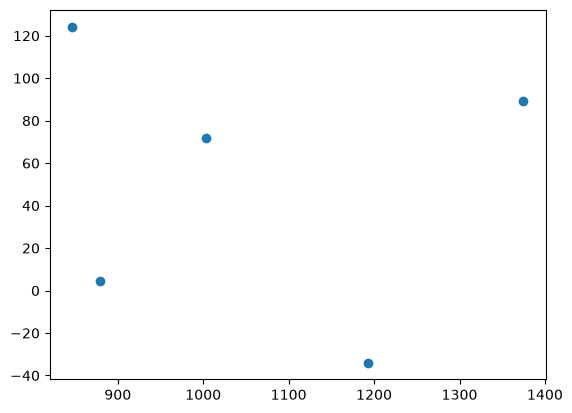

In [71]:
#scatter plot wrt prediction and residuals
plt.scatter(y_pred, residuals)

In [72]:
#OLS regression assumptions
import statsmodels.api as sm
model = sm.OLS(y_train, X_train).fit()
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.033
Model:                            OLS   Adj. R-squared (uncentered):             -0.081
Method:                 Least Squares   F-statistic:                             0.2916
Date:                Wed, 22 Jul 2026   Prob (F-statistic):                       0.751
Time:                        02:56:41   Log-Likelihood:                         -159.34
No. Observations:                  19   AIC:                                      322.7
Df Residuals:                      17   BIC:                                      324.6
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------